# Task 4: Predicting Insurance Claim Amounts

## Introduction

This notebook is part of my Data Science & Analytics Internship at DevelopersHub Corporation. The objective of this task is to build a machine learning model that estimates medical insurance charges based on a customer's personal details such as age, BMI, and smoking status.

## Problem Statement

I am working with the Medical Cost Personal Dataset from Kaggle. It contains 1,338 records with 7 columns including age, BMI, number of children, smoking status, region, and medical charges. Unlike previous tasks, this is a Regression problem. The model predicts an actual dollar amount rather than a category. Performance is measured using MAE and RMSE instead of accuracy and confusion matrix.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('insurance.csv')
print("Dataset loaded successfully")
print(df.shape)
df.head()

Dataset loaded successfully
(1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
print("Column names and Data types")
df.dtypes

Column names and Data types


age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [4]:
print("Missing values in each column: ") 
df.isnull().sum()

Missing values in each column: 


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [5]:
print("Unique value count for each column: ")
for col in df.columns:
    print(col, df[col].nunique())

Unique value count for each column: 
age 47
sex 2
bmi 548
children 6
smoker 2
region 4
charges 1337


In [6]:
print("Unique values in region column: ")
df['region'].value_counts()

Unique values in region column: 


region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [7]:
# Label Encoding
le = LabelEncoder()
for col in ['sex','smoker']:
    df[col]=le.fit_transform(df[col])
# One-Hot Encoding
df = pd.get_dummies(df, columns = ['region'], drop_first = True)
print("Data after Encoding")
df.head()

Data after Encoding


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


In [8]:
# EDA
sns.set(style='whitegrid')

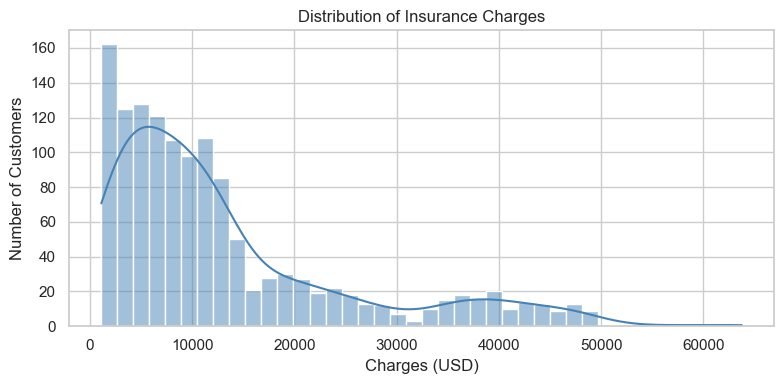

In [9]:
# Distribution of Insurance Charges
# PURPOSE: What does the spread of charges look like?
# Are most charges low with a few very expensive cases?
# This tells us if the target variable is skewed.

plt.figure(figsize = (8,4))
sns.histplot(df['charges'], bins = 40, kde = True, color= 'steelblue')
plt.title("Distribution of Insurance Charges")
plt.xlabel('Charges (USD)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

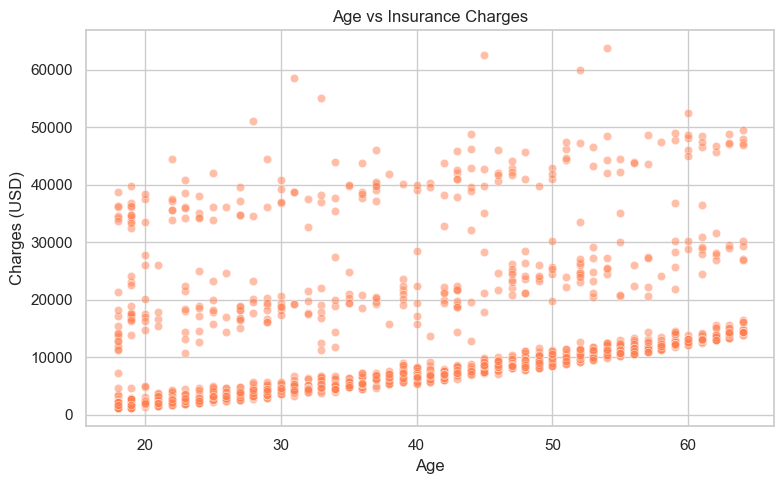

In [10]:
# Age vs. Charges
# PURPOSE: Do older people pay more in insurance charges?
# A scatter plot shows each customer as a dot. We can see if there is a pattern as age increases.
plt.figure(figsize = (8,5))
sns.scatterplot(x = 'age', y='charges', data=df, alpha = 0.5, color = 'coral')
plt.title('Age vs Insurance Charges')
plt.xlabel('Age')
plt.ylabel('Charges (USD)')
plt.tight_layout()
plt.show()

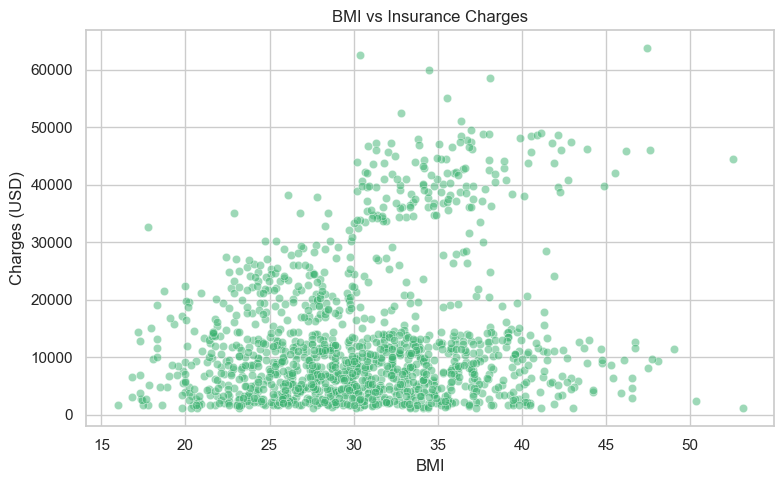

In [11]:
# BMI vs. Charges
#PURPOSE: Does higher BMI lead to higher charges?
# Higher BMI = more health risks = potentially more medical costs

plt.figure(figsize=(8, 5))
sns.scatterplot(x='bmi', y='charges', data=df, alpha=0.5, color='mediumseagreen')
plt.title('BMI vs Insurance Charges')
plt.xlabel('BMI')
plt.ylabel('Charges (USD)')
plt.tight_layout()
plt.show()
# shows almost no visible relationship with charges

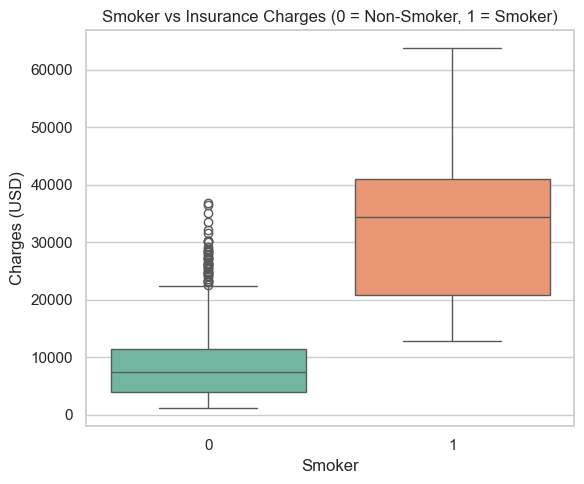

In [12]:
# Smoker vs. Charges
# PURPOSE: How much more do smokers pay compared to non-smokers?
plt.figure(figsize=(6, 5))
sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')
plt.title('Smoker vs Insurance Charges (0 = Non-Smoker, 1 = Smoker)')
plt.xlabel('Smoker')
plt.ylabel('Charges (USD)')
plt.tight_layout()
plt.show()

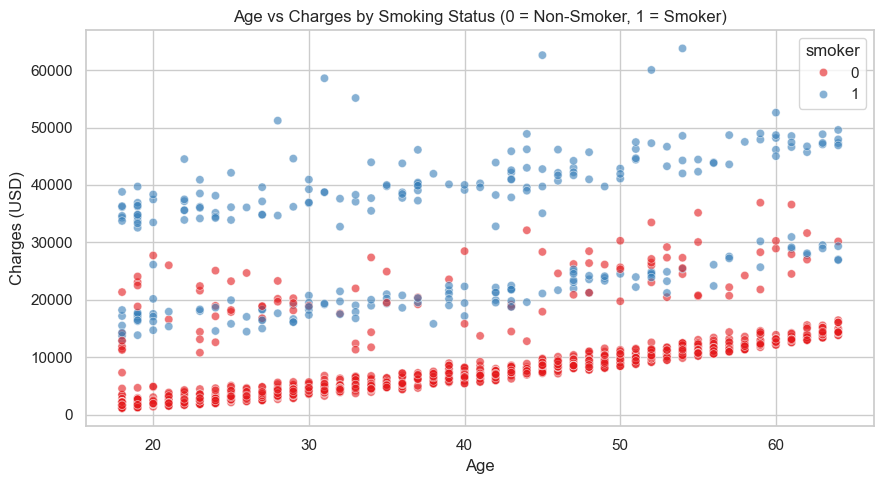

In [13]:
# Age vs. Charges colored by Smoker status
# PURPOSE: Combines two important features in one chart.
# Shows how age and smoking together affect charges.
# Are young smokers already paying more than old non-smokers?

plt.figure(figsize=(9, 5))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, alpha=0.6, palette='Set1')
plt.title('Age vs Charges by Smoking Status (0 = Non-Smoker, 1 = Smoker)')
plt.xlabel('Age')
plt.ylabel('Charges (USD)')
plt.tight_layout()
plt.show()

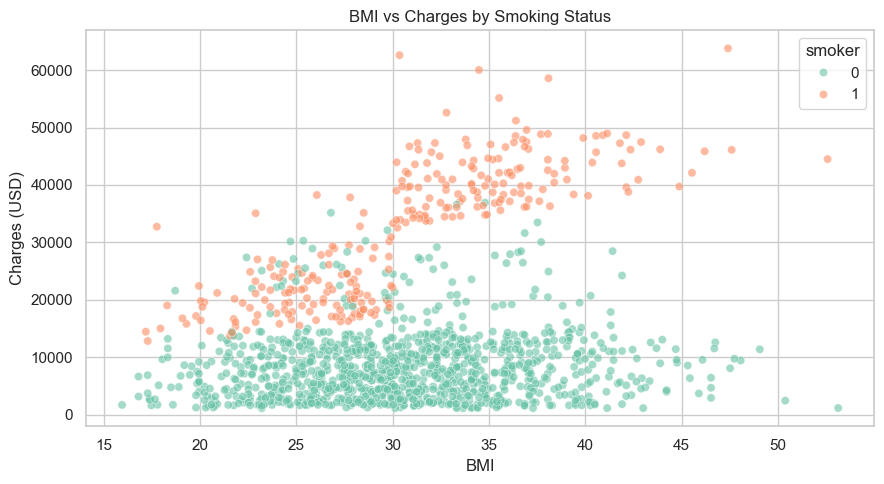

In [14]:
# BMI vs. Charges colored by Smoker status
# PURPOSE: Does high BMI matter more for smokers than non-smokers?

plt.figure(figsize=(9, 5))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, alpha=0.6, palette='Set2')
plt.title('BMI vs Charges by Smoking Status')
plt.xlabel('BMI')
plt.ylabel('Charges (USD)')
plt.tight_layout()
plt.show()

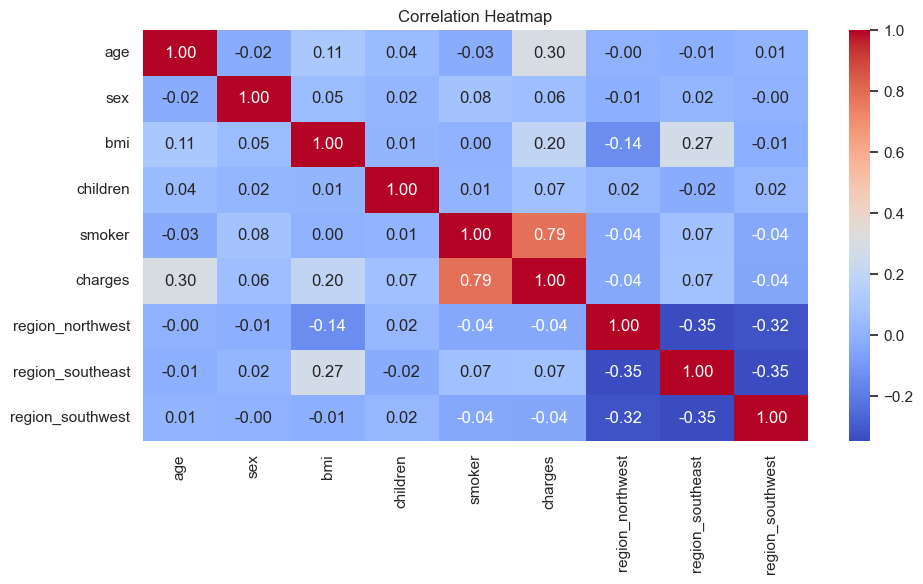

In [15]:
# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [16]:
# Prepare data for machine learning
X = df.drop('charges', axis = 1)
y = df['charges']
print('Features (X)',X.shape)
print('Target (Y)',y.shape)
print('Feature columns: ',X.columns.tolist())

Features (X) (1338, 8)
Target (Y) (1338,)
Feature columns:  ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']


In [17]:
# Split into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42)
print("Training set size: ", X_train.shape)
print("Testing set size: ", X_test.shape)

Training set size:  (1070, 8)
Testing set size:  (268, 8)


In [18]:
# Train the Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("Linear Regression Model Trained Successfully")
coefficients = pd.DataFrame({
    'Feature' : X.columns,
    'Coefficient' : lr_model.coef_
})
coefficients = coefficients.sort_values('Coefficient', ascending=False)
print("\nModel Coefficients (how much each feature affects charges):")
print(coefficients)

Linear Regression Model Trained Successfully

Model Coefficients (how much each feature affects charges):
            Feature   Coefficient
4            smoker  23651.128856
3          children    425.278784
2               bmi    337.092552
0               age    256.975706
1               sex    -18.591692
5  region_northwest   -370.677326
6  region_southeast   -657.864297
7  region_southwest   -809.799354


In [19]:
# Make Predictions
lr_predictions = lr_model.predict(X_test)
print("First 5 predicted charges: ", lr_predictions[:5])
print("First 5 actual charges: ", list(y_test[:5]))

First 5 predicted charges:  [ 8969.55027444  7068.74744287 36858.41091155  9454.67850053
 26973.17345656]
First 5 actual charges:  [9095.06825, 5272.1758, 29330.98315, 9301.89355, 33750.2918]


In [22]:
# Evaluate Model
mae = mean_absolute_error(y_test, lr_predictions)
mse = mean_squared_error(y_test, lr_predictions)
rmse = np.sqrt(mse)
print(f"Mean absolute error: ${mae:,.2f}")
print(f"Mean Square error: ${mse:,.2f}")
print(f"On average, predictions are off by ${mae:,.2f}")
print(f"Large errors are penalized more — RMSE of ${rmse:,.2f} reflects this")

Mean absolute error: $4,181.19
Mean Square error: $33,596,915.85
On average, predictions are off by $4,181.19
Large errors are penalized more — RMSE of $5,796.28 reflects this


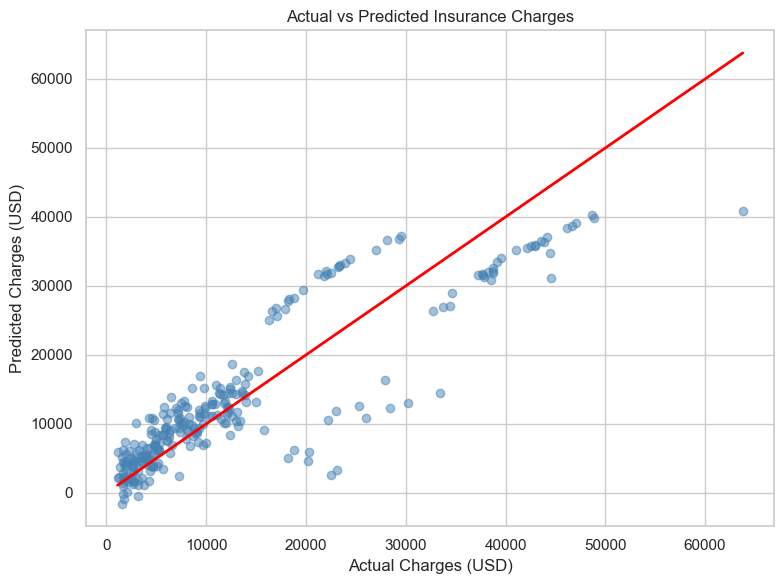

In [23]:
# Visualize actual vs. predicted charges

plt.figure(figsize=(8,6))
plt.scatter(y_test,lr_predictions,alpha =0.5,color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2)
plt.title('Actual vs Predicted Insurance Charges')
plt.xlabel('Actual Charges (USD)')
plt.ylabel('Predicted Charges (USD)')
plt.tight_layout()
plt.show()

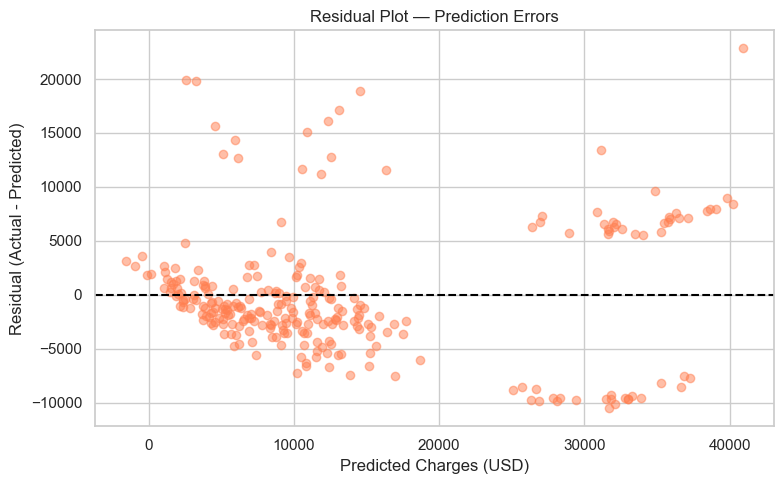

In [25]:
# Visualize prediction errors

residuals = y_test - lr_predictions
# Calculate the error for each prediction
plt.figure(figsize=(8, 5))
plt.scatter(lr_predictions, residuals, alpha=0.5, color='coral')
plt.axhline(y=0, color='black', linewidth=1.5, linestyle='--')
# axhline: draws a horizontal line at y=0
plt.title('Residual Plot — Prediction Errors')
plt.xlabel('Predicted Charges (USD)')
plt.ylabel('Residual (Actual - Predicted)')
plt.tight_layout()
plt.show()

## Conclusion and Key Insights

**Key Findings**
- Smoking status was the strongest predictor of insurance charges with a correlation of 0.79, far above every other feature
- Being a smoker adds approximately USD 23,651 to predicted charges on average, based on the model's learned coefficients
- Age showed moderate influence at 0.30 correlation, each additional year adds roughly USD 257 to charges
- BMI alone was a weak predictor at 0.20 correlation, but the scatter plot revealed that BMI strongly affects charges specifically for smokers, high    BMI combined with smoking creates dramatically higher charges
- Sex, number of children, and region had minimal impact on charges

**Model Performance**
- MAE of USD 4,181 means predictions are off by USD 4,181 on average
- RMSE of USD 5,796 is higher than MAE, which confirms that a subset of predictions have large errors, the model struggles most with high-charge        customers
- The residual plot showed a downward pattern rather than a random cloud, indicating the model consistently over-predicts for expensive cases, a sign   that the relationship between smoking and charges is non-linear, which Linear Regression cannot fully capture

**Final Takeaway**
Smoking status alone accounts for most of the variation in insurance charges in this dataset. A customer who smokes will almost always pay significantly more regardless of their age, BMI, or region. A more advanced model such as Random Forest would likely reduce the MAE and RMSE by capturing the non-linear interaction between smoking and BMI that Linear Regression misses.